In [1]:
!pip install xlrd --quiet
!pip install pynsee --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pynsee
import pynsee.download

In [3]:
np.random.seed(42)

In [4]:
url = "https://koumoul.com/s/data-fair/api/v1/datasets/igt-pouvoir-de-rechauffement-global/convert"
emissions = pd.read_csv(url)
emissions.head(2)

,INSEE commune,Commune,Agriculture,Autres transports,Autres transports international,CO2 biomasse hors-total,Déchets,Energie,Industrie hors-énergie,Résidentiel,Routier,Tertiaire
0,01001,L'ABERGEMENT-CLEMENCIAT,3711.425991,NaN,NaN,432.751835,101.430476,2.354558,6.911213,309.358195,793.156501,367.036172
1,01002,L'ABERGEMENT-DE-VAREY,475.330205,NaN,NaN,140.741660,140.675439,2.354558,6.911213,104.866444,348.997893,112.934207


# EXO 1 

1. Calculer les émissions totales du secteur “Résidentiel” par département, puis rapporter ces valeurs à celle du département le plus émetteur dans ce domaine. Que pouvez-vous en conclure ?
2. Calculer, pour chaque département, les émissions totales de chaque secteur en pourcentage des émissions totales du département. Que pouvez-vous en conclure ?

In [5]:
emissions['departement'] = emissions['INSEE commune'].astype(str).str[:2]
emissions_dep = emissions.groupby('departement')['Résidentiel'].sum()
max_value = emissions_dep.max()
ratio = emissions_dep / max_value
resultat = pd.DataFrame({
    'Emissions_residentiel': emissions_dep,
    'Ratio': ratio
}).sort_values('Emissions_residentiel', ascending=False)
resultat

,Emissions_residentiel,Ratio
departement,,
59,3.498347e+06,1.000000
75,1.934580e+06,0.552998
69,1.774653e+06,0.507283
62,1.738090e+06,0.496832
57,1.644192e+06,0.469991
...,...,...
05,1.224274e+05,0.034996
04,1.168361e+05,0.033398
2B,7.710984e+04,0.022042


**Conclusion** : Ce classement reflète peut-être plus la démographie que le processus qu’on désire mesurer. Sans l’ajout d’une information annexe sur la population de chaque département pour contrôler ce facteur, on peut difficilement savoir s’il y a une différence structurelle de comportement entre les habitants du Nord (département 59) et ceux de la Moselle (département 57).

In [6]:
secteurs = [
    "Agriculture", "Autres transports", "Autres transports international",
    "CO2 biomasse hors-total", "Déchets", "Energie",
    "Industrie hors-énergie", "Résidentiel", "Routier", "Tertiaire"
]
emissions_dep_secteur = emissions.groupby("departement")[secteurs].sum()
emissions_totales_dep = emissions_dep_secteur.sum(axis=1)
emissions_dep_secteur

,Agriculture,Autres transports,Autres transports international,CO2 biomasse hors-total,Déchets,Energie,Industrie hors-énergie,Résidentiel,Routier,Tertiaire
departement,,,,,,,,,,
01,8.075850e+05,15647.945725,2.581109e+02,7.119048e+05,275415.025873,113596.600977,706549.858520,5.522627e+05,1.635350e+06,418646.522003
02,1.276261e+06,58834.836998,2.521642e+03,6.174937e+05,180245.578283,60366.151368,737319.268428,6.388608e+05,1.386403e+06,325014.134252
03,1.949985e+06,19686.272920,5.451597e+02,5.659226e+05,111219.488315,102975.024821,457513.404309,4.457248e+05,1.164762e+06,224487.970942
04,3.632657e+05,5851.619941,0.000000e+00,1.160564e+05,50541.206026,12184.836311,60899.229209,1.168361e+05,3.905682e+05,98228.256513
05,3.103814e+05,6216.001726,0.000000e+00,8.433816e+04,22268.075401,5455.510286,16013.281334,1.224274e+05,3.458587e+05,77885.624538
...,...,...,...,...,...,...,...,...,...,...
91,1.565447e+05,839544.846964,1.257594e+06,7.285136e+05,293317.174006,105597.205576,368638.793346,1.280296e+06,2.073377e+06,757884.411113
92,9.140818e+01,12340.794839,2.101194e+02,1.067889e+06,264497.880711,242842.018012,706597.424067,1.466794e+06,1.198420e+06,836013.153414
93,2.018471e+03,59617.086124,1.101400e+06,7.259516e+05,252166.943778,102837.663903,433216.360990,1.316452e+06,1.396911e+06,863017.791777


In [7]:
proportions = emissions_dep_secteur.div(emissions_totales_dep, axis=0)
proportions


,Agriculture,Autres transports,Autres transports international,CO2 biomasse hors-total,Déchets,Energie,Industrie hors-énergie,Résidentiel,Routier,Tertiaire
departement,,,,,,,,,,
01,0.154201,0.002988,0.000049,0.135932,0.052588,0.021690,0.134909,0.105450,0.312256,0.079937
02,0.241564,0.011136,0.000477,0.116876,0.034116,0.011426,0.139556,0.120920,0.262411,0.061517
03,0.386685,0.003904,0.000108,0.112223,0.022055,0.020420,0.090726,0.088388,0.230974,0.044516
04,0.299124,0.004818,0.000000,0.095564,0.041617,0.010033,0.050146,0.096206,0.321606,0.080884
05,0.313249,0.006273,0.000000,0.085117,0.022474,0.005506,0.016161,0.123559,0.349055,0.078605
...,...,...,...,...,...,...,...,...,...,...
91,0.019913,0.106795,0.159973,0.092671,0.037312,0.013433,0.046893,0.162860,0.263745,0.096407
92,0.000016,0.002129,0.000036,0.184255,0.045637,0.041900,0.121918,0.253083,0.206778,0.144247
93,0.000323,0.009533,0.176123,0.116086,0.040324,0.016445,0.069275,0.210511,0.223378,0.138004


**Conclusion**: 

Si on se focus sur les émissions de l’agriculture et du secteur tertiaire uniquement : 

Ces résultats apparaissent cohérents : les départements à dominante rurale présentent une part plus élevée de leurs émissions issue du secteur agricole, tandis que les départements urbains concentrent davantage d’émissions provenant du secteur tertiaire, ce qui s’explique notamment par une densité plus forte de population et d’activités.

L’analyse de ces statistiques permet ainsi d’approfondir la compréhension de notre jeu de données et de mieux caractériser la structure des émissions de CO₂ en France. Les statistiques descriptives par groupe offrent un éclairage pertinent sur l’hétérogénéité spatiale du phénomène étudié.

Néanmoins, l’interprétation de ces résultats demeure limitée en l’absence d’informations complémentaires. Une statistique ne prend pleinement sens et valeur analytique que lorsqu’elle est mise en regard de connaissances externes ; sans ce cadre interprétatif, elle risque de rester abstraite et peu informative.

# Exo 2
<div style="padding: 12px;"> 1. Vérifier les dimensions des DataFrames.<br> 2. Identifier dans <code>filosofi</code> les noms de communes qui correspondent à plusieurs codes communes et sélectionner leurs codes. En d’autres termes, identifier les <code>LIBGEO</code> tels qu’il existe des doublons de <code>CODGEO</code> et les stocker dans un vecteur <code>x</code> (conseil: faire attention à l’index de <code>x</code>).<br> 3. Regarder dans <code>filosofi</code> les observations où le libellé comporte plus de deux codes communes différents.<br> 4. Réordonner la base obtenue par order alphabétique.<br> 5. Déterminer la taille moyenne des communes (variable nombre de personnes: NBPERSMENFISC16) et quelques statistiques descriptives de ces données. Comparer aux mêmes statistiques sur les données où libellés et codes communes coïncident.<br> 6. Vérifier les grandes villes (&gt; 100 000 habitants) et regarder la proportion pour lequelles un même nom est associé à différents codes commune.<br> 7. Vérifier dans <code>filosofi</code> combien de villes sont nommées "Montreuil". De même avec celle qui contiennent "Saint-Denis".<br> 8. Quelles conclusions peut-on tirer de cet exercice ?<br> </div>


### 1.

In [15]:
url = "https://koumoul.com/s/data-fair/api/v1/datasets/igt-pouvoir-de-rechauffement-global/convert"
emissions = pd.read_csv(url)

from pynsee.download import download_file
filosofi = download_file("FILOSOFI_COM_2016")

url_cog_2023 = "https://www.insee.fr/fr/statistiques/fichier/6800675/v_commune_2023.csv"
cog_2023 = pd.read_csv(url_cog_2023)

In [16]:
print("emissions shape : ", emissions.shape,"\n COG shape :", cog_2023.shape, "\n filosophi shape : " , filosofi.shape  )

emissions shape :  (35798, 12) 
 COG shape : (37563, 12) 
 filosophi shape :  (34932, 29)


Chacune de ces bases de données sont censé être au niveau communal, et aucune n'a le même nombre de commune/observation/ligne. 

### 2.

In [19]:
# Compter le nombre de codes distincts par nom de commune
libgeo_multi = (
    filosofi
    .groupby("LIBGEO")["CODGEO"]
    .nunique()
)

# Sélectionner ceux ayant plusieurs codes
libgeo_multi = libgeo_multi[libgeo_multi > 1].index

x = (
    filosofi
    .loc[filosofi["LIBGEO"].isin(libgeo_multi), "CODGEO"]
    .unique()
)

### 3.

In [25]:
libgeo_ambigus = filosofi[filosofi["CODGEO"].isin(x)]

### 4.

In [26]:
libgeo_ambigus.sort_values("LIBGEO")

,CODGEO,LIBGEO,NBMENFISC16,NBPERSMENFISC16,MED16,PIMP16,TP6016,TP60AGE116,TP60AGE216,TP60AGE316,...,PPEN16,PPAT16,PPSOC16,PPFAM16,PPMINI16,PPLOGT16,PIMPOT16,D116,D916,RD16
21815,59001,Abancourt,182,477,22772,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
22463,60001,Abancourt,249,605.5,18545.625,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
20781,57001,Aboncourt,125,339,20887.2,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
19449,54003,Aboncourt,48,109.5,18586.153846153844,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
12323,33001,Abzac,801,1880.5,18786,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6118,18090,Étréchy,191,433,19814.666666666668,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
34440,91226,Étréchy,2756,6585,25032.5,70,6,None,None,None,...,35,8.5,2.8,1.5,0.7,0.6,-18.8,14681.714285714286,39019.333333333336,2.6576823778201586
18388,51239,Étréchy,46,111.5,21155.23809523809,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
30178,77173,Étrépilly,291,831.5,23500.8,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None


### 5.

In [ ]:
libgeo_non_ambigus = filosofi[~filosofi["CODGEO"].isin(x)] # ~ est équivalent à NOT
libgeo_non_ambigus

,CODGEO,LIBGEO,NBMENFISC16,NBPERSMENFISC16,MED16,PIMP16,TP6016,TP60AGE116,TP60AGE216,TP60AGE316,...,PPEN16,PPAT16,PPSOC16,PPFAM16,PPMINI16,PPLOGT16,PIMPOT16,D116,D916,RD16
0,01001,L'Abergement-Clémenciat,313,795.5,22679,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1,01002,L'Abergement-de-Varey,101,248,24382.083333333336,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
2,01004,Ambérieu-en-Bugey,6363,14228,19721,49,17,19,22,22,...,27,8.8,6.9,2.8,2.1,2,-15.7,10457.083333333334,33880.555555555555,3.239962279688143
3,01005,Ambérieux-en-Dombes,633,1662.5,23378,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
4,01006,Ambléon,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34926,97419,Sainte-Rose,2308,6710,11638.387096774191,13,55,None,65,59,...,14.5,3.6,25.1,6.1,14.5,4.4,-8.6,6420,24337.82608695652,3.7909386428281184
34928,97421,Salazie,2358,6967,11280.9375,12,58,None,63,61,...,14.6,4.5,25.1,6.2,15.9,3,-8,5758.780487804878,23529.33333333333,4.085818756794149
34929,97422,Le Tampon,27916,73468.5,14243.809523809525,25,41,56,45,43,...,20.2,7.8,16.8,4.3,8.5,3.9,-11.8,7434.193548387097,32987.6,4.437280222164367
34930,97423,Les Trois-Bassins,2386,7105,14031.785714285716,23,42,None,42,41,...,13.6,4,16.5,4.6,9.7,2.2,-10.6,7575.333333333334,28596.567164179105,3.7749582633343883


In [29]:
stats_ambigus = libgeo_ambigus["NBPERSMENFISC16"].describe()
stats_non_ambigus = libgeo_non_ambigus["NBPERSMENFISC16"].describe()
comparaison = pd.DataFrame({
    "Communes_ambigues": stats_ambigus,
    "Communes_non_ambigues": stats_non_ambigus
})

comparaison

,Communes_ambigues,Communes_non_ambigues
count,3302,28103
unique,1953,7532
top,198,108
freq,12,54


### 6.

In [32]:
filosofi["NBPERSMENFISC16"] = pd.to_numeric(
    filosofi["NBPERSMENFISC16"],
    errors="coerce"
)
pop_commune = (
    filosofi
    .groupby("CODGEO")["NBPERSMENFISC16"]
    .sum()
    .reset_index()
)

grandes_villes = pop_commune[pop_commune["NBPERSMENFISC16"] > 100_000]

In [33]:
grandes_villes["ambigue"] = grandes_villes["CODGEO"].isin(x)

/tmp/ipykernel_955491/2966271593.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grandes_villes["ambigue"] = grandes_villes["CODGEO"].isin(x)


In [34]:
proportion = grandes_villes["ambigue"].mean()

nb_total = len(grandes_villes)
nb_ambigues = grandes_villes["ambigue"].sum()

print("Grandes villes :", nb_total)
print("Grandes villes ambiguës :", nb_ambigues)
print("Proportion :", proportion)

Grandes villes : 48
Grandes villes ambiguës : 4
Proportion : 0.08333333333333333


### 7.

In [35]:
montreuil = filosofi[filosofi["LIBGEO"] == "Montreuil"]

nb_montreuil = montreuil["CODGEO"].nunique()

print("Nombre de communes nommées exactement 'Montreuil' :", nb_montreuil)

saint_denis = filosofi[
    filosofi["LIBGEO"].str.contains("Saint-Denis", case=False, na=False)
]

nb_saint_denis = saint_denis["CODGEO"].nunique()

print("Nombre de communes contenant 'Saint-Denis' :", nb_saint_denis)

Nombre de communes nommées exactement 'Montreuil' : 4
Nombre de communes contenant 'Saint-Denis' : 60


### 8.

Les libellés dupliqués sont en fait des noms de commune identiques mais qui ne sont pas dans le même département. Il ne s’agit donc pas d’observations dupliquées. On peut donc se fier aux codes communes, qui eux sont uniques.

# EXO 3

<div style="padding: 12px;"> 1. Créer une variable <code>emissions</code> qui correspond aux émissions totales d’une commune.<br> 2. Faire une jointure à gauche entre les données d’émissions et les données de cadrage.<br> 3. Calculer l’empreinte carbone (émissions totales / population). <br> 4. Faire un histogramme de l’empreinte carbone et un autre du log de l'empreinte carbone.<br> 5. Regarder la corrélation entre les variables et l’empreinte carbone. Certaines variables semblent-elles pouvoir potentiellement influer sur l’empreinte carbone ? </div>

In [41]:
url = "https://koumoul.com/s/data-fair/api/v1/datasets/igt-pouvoir-de-rechauffement-global/convert"
emissions = pd.read_csv(url)
emissions

,INSEE commune,Commune,Agriculture,Autres transports,Autres transports international,CO2 biomasse hors-total,Déchets,Energie,Industrie hors-énergie,Résidentiel,Routier,Tertiaire
0,01001,L'ABERGEMENT-CLEMENCIAT,3711.425991,NaN,NaN,432.751835,101.430476,2.354558,6.911213,309.358195,793.156501,367.036172
1,01002,L'ABERGEMENT-DE-VAREY,475.330205,NaN,NaN,140.741660,140.675439,2.354558,6.911213,104.866444,348.997893,112.934207
2,01004,AMBERIEU-EN-BUGEY,499.043526,212.577908,NaN,10313.446515,5314.314445,998.332482,2930.354461,16616.822534,15642.420313,10732.376934
3,01005,AMBERIEUX-EN-DOMBES,1859.160954,NaN,NaN,1144.429311,216.217508,94.182310,276.448534,663.683146,1756.341319,782.404357
4,01006,AMBLEON,448.966808,NaN,NaN,77.033834,48.401549,NaN,NaN,43.714019,398.786800,51.681756
...,...,...,...,...,...,...,...,...,...,...,...,...
35793,95676,VILLERS-EN-ARTHIES,1628.065094,NaN,NaN,165.045396,65.063617,11.772789,34.556067,176.098160,309.627908,235.439109
35794,95678,VILLIERS-ADAM,698.630772,NaN,NaN,1331.126598,111.480954,2.354558,6.911213,1395.529811,18759.370071,403.404815
35795,95680,VILLIERS-LE-BEL,107.564967,NaN,NaN,8367.174532,225.622903,534.484607,1568.845431,22613.830247,12217.122402,13849.512001
35796,95682,VILLIERS-LE-SEC,1090.890170,NaN,NaN,326.748418,108.969749,2.354558,6.911213,67.235487,4663.232127,85.657725


### 1.

In [44]:
emissions['emissions'] = emissions.sum(axis = 1, numeric_only = True)
emissions[['INSEE commune','Commune', 'emissions']]

,INSEE commune,Commune,emissions
0,01001,L'ABERGEMENT-CLEMENCIAT,17173.274824
1,01002,L'ABERGEMENT-DE-VAREY,3998.434857
2,01004,AMBERIEU-EN-BUGEY,189779.067356
3,01005,AMBERIEUX-EN-DOMBES,20378.602318
4,01006,AMBLEON,3205.754299
...,...,...,...
35793,95676,VILLERS-EN-ARTHIES,7877.004421
35794,95678,VILLIERS-ADAM,68126.426376
35795,95680,VILLIERS-LE-BEL,178452.471272
35796,95682,VILLIERS-LE-SEC,19055.998341


### 2.

In [46]:
emissions_merged = (
    emissions.reset_index()
    .merge(filosofi, left_on = "INSEE commune", right_on = "CODGEO")
)
emissions_merged

,index,INSEE commune,Commune,Agriculture,Autres transports,Autres transports international,CO2 biomasse hors-total,Déchets,Energie,Industrie hors-énergie,...,PPEN16,PPAT16,PPSOC16,PPFAM16,PPMINI16,PPLOGT16,PIMPOT16,D116,D916,RD16
0,0,01001,L'ABERGEMENT-CLEMENCIAT,3711.425991,NaN,NaN,432.751835,101.430476,2.354558,6.911213,...,None,None,None,None,None,None,None,None,None,None
1,1,01002,L'ABERGEMENT-DE-VAREY,475.330205,NaN,NaN,140.741660,140.675439,2.354558,6.911213,...,None,None,None,None,None,None,None,None,None,None
2,2,01004,AMBERIEU-EN-BUGEY,499.043526,212.577908,NaN,10313.446515,5314.314445,998.332482,2930.354461,...,27,8.8,6.9,2.8,2.1,2,-15.7,10457.083333333334,33880.555555555555,3.239962279688143
3,3,01005,AMBERIEUX-EN-DOMBES,1859.160954,NaN,NaN,1144.429311,216.217508,94.182310,276.448534,...,None,None,None,None,None,None,None,None,None,None
4,4,01006,AMBLEON,448.966808,NaN,NaN,77.033834,48.401549,NaN,NaN,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34866,35793,95676,VILLERS-EN-ARTHIES,1628.065094,NaN,NaN,165.045396,65.063617,11.772789,34.556067,...,None,None,None,None,None,None,None,None,None,None
34867,35794,95678,VILLIERS-ADAM,698.630772,NaN,NaN,1331.126598,111.480954,2.354558,6.911213,...,None,None,None,None,None,None,None,None,None,None
34868,35795,95680,VILLIERS-LE-BEL,107.564967,NaN,NaN,8367.174532,225.622903,534.484607,1568.845431,...,17,3.6,14.8,6.2,4.5,4.2,-11.9,8369.302325581395,25531.42857142857,3.0506041696438495
34869,35796,95682,VILLIERS-LE-SEC,1090.890170,NaN,NaN,326.748418,108.969749,2.354558,6.911213,...,None,None,None,None,None,None,None,None,None,None


### 3.

In [48]:
emissions_merged['empreinte'] = emissions_merged['emissions']/emissions_merged['NBPERSMENFISC16']
emissions_merged['empreinte'] = emissions_merged['empreinte'].astype(float)
emissions_merged[['INSEE commune','Commune', 'empreinte']].sort_values(by="empreinte")

,INSEE commune,Commune,empreinte
4719,14406,MARTRAGNY,2.969304
32745,85146,MONTAIGU,3.888212
32785,85194,LES SABLES-D'OLONNE,3.953085
14398,38395,SAINT-HILAIRE,4.014541
27142,69159,POUILLY-LE-MONIAL,4.096995
...,...,...,...
34749,95214,EPINAY-CHAMPLATREUX,NaN
34793,95387,MENOUVILLE,NaN
34823,95492,LE PLESSIS-GASSOT,NaN
34852,95611,THEUVILLE,NaN


### 4.

In [ ]:

emissions_merged['empreinte'].describe()

<Axes: ylabel='Frequency'>

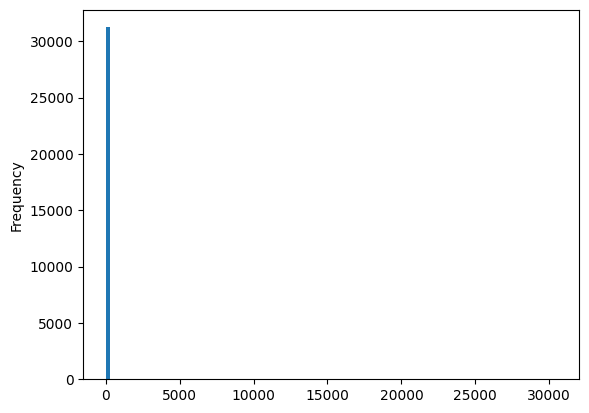

In [57]:
emissions_merged['empreinte'].plot(kind = 'hist', bins = 100)

<Axes: ylabel='Frequency'>

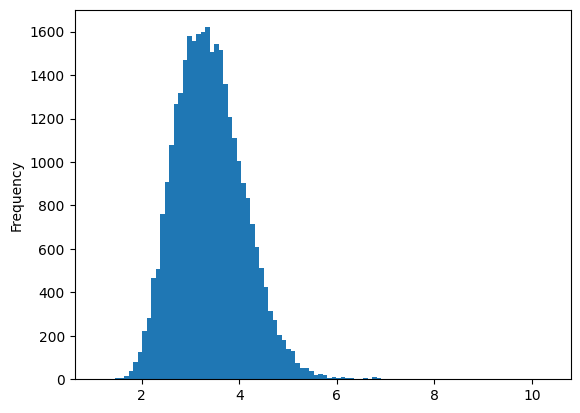

In [56]:
np.log(emissions_merged['empreinte']).plot(kind = 'hist', bins = 100)